In [128]:
import scanpy as sc
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd
import numpy as np

## Load the annotated data 

In [142]:
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/replicate/reannot/adata_500k.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/replicate/reannot/adata_loop_2p5_500k_residual.h5ad")

In [143]:
adata_tot = sc.concat([adata_loop2, adata_loop2p5])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [144]:
# sc.pl.umap(adata, color="cell_type_reannot_final", s=20)

In [145]:
exp_to_mgk = {"experiment_number": [], "proportions": []}
exp_to_ery = {"experiment_number": [], "proportions": []}

In [146]:
for experiment_number in adata_tot.obs.experiment_number.unique():
    adata_exp = adata_tot[adata_tot.obs.experiment_number==experiment_number]
    cell_type_counts = adata_exp.obs.cell_type_reannot_final.value_counts() / adata_exp.shape[0]
    # prop_mgkproery = cell_type_counts[cell_type_counts.index.isin(["EryPro", "late_MgkPro", "MgKEryPro1", "MgKEryPro2"])].sum()
    prop_mgk = cell_type_counts[cell_type_counts.index.isin(["late_MgkPro"])].sum()
    prop_ery = cell_type_counts[cell_type_counts.index.isin(["EryPro"])].sum()    
    exp_to_mgk["experiment_number"].append(experiment_number)
    exp_to_mgk["proportions"].append(prop_mgk)
    exp_to_ery["experiment_number"].append(experiment_number)
    exp_to_ery["proportions"].append(prop_ery)

In [147]:
exp_to_mgk_df = pd.DataFrame(exp_to_mgk)
exp_to_mgk_df = exp_to_mgk_df.set_index("experiment_number")
# exp_to_mgk_ery_df[exp_to_mgk_ery_df.proportions>exp_to_mgk_ery_df.loc["242"].proportions].shape

In [148]:
exp_ery_df = pd.DataFrame(exp_to_ery)
exp_ery_df = exp_ery_df.set_index("experiment_number")
# exp_to_mgk_ery_df[exp_to_mgk_ery_df.proportions>exp_to_mgk_ery_df.loc["242"].proportions].shape

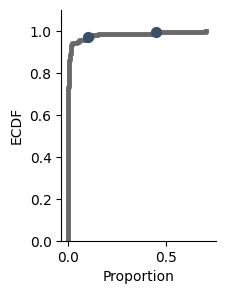

Exp. 239: proportion = 0.447, 0.7% of old protocols exceed it
Exp. 240: proportion = 0.101, 3.0% of old protocols exceed it


In [149]:
fig, ax = plt.subplots(figsize=(2, 3))

# ECDF
sns.ecdfplot(
    data=exp_to_mgk_df,
    x="proportions",
    ax=ax,
    linewidth=3.5,
    color="dimgray"
)

# Prepare ECDF computation
x = np.sort(exp_to_mgk_df["proportions"].values)
n = len(x)
xs = []
ys = []

# Dot annotations
for exp, color in zip(["239", "240"], ["#3a4f6a", "#3a4f6a"]):
    x_val = exp_to_mgk_df.loc[exp, "proportions"]
    y_val = np.searchsorted(x, x_val, side="right") / n
    xs.append(x_val)
    ys.append(y_val)
    ax.scatter(
        x_val,
        y_val,
        color=color,
        s=50,
        zorder=5
    )

# ---- FIX: expand limits so dots never clip ----
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.set_xlim(min(xmin, min(xs)) * 0.98, max(xmax, max(xs)) * 1.02)
ax.set_ylim(min(ymin, min(ys)) * 0.98, max(ymax, max(ys)) * 1.1)

ax.set_xlabel("Proportion")
ax.set_ylabel("ECDF")
sns.despine()
ax.grid(False)

plt.savefig("ecdf_mgk.svg", bbox_inches="tight", facecolor="white")
plt.show()

# ---- Print "% exceed" for each highlighted point ----
for exp, x_val, y_val in zip(["239", "240"], xs, ys):
    pct_exceed = (1 - y_val) * 100
    print(f"Exp. {exp}: proportion = {x_val:.3f}, {pct_exceed:.1f}% of old protocols exceed it")

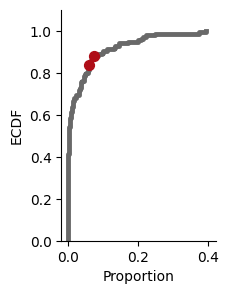

Exp. 241: proportion = 0.061, 16.3% of old protocols exceed it
Exp. 242: proportion = 0.074, 11.9% of old protocols exceed it


In [150]:
fig, ax = plt.subplots(figsize=(2, 3))

# ECDF
sns.ecdfplot(
    data=exp_ery_df,
    x="proportions",
    ax=ax,
    linewidth=3.5,
    color="dimgray"
)

# Prepare ECDF computation
x = np.sort(exp_ery_df["proportions"].values)
n = len(x)
xs = []
ys = []

# Dot annotations
for exp, color in zip(["241", "242"], ["#af0e18", "#af0e18"]):
    x_val = exp_ery_df.loc[exp, "proportions"]
    y_val = np.searchsorted(x, x_val, side="right") / n
    xs.append(x_val)
    ys.append(y_val)
    ax.scatter(
        x_val,
        y_val,
        color=color,
        s=50,
        zorder=5
    )

# ---- FIX: expand limits so dots never clip ----
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.set_xlim(min(xmin, min(xs)) * 0.98, max(xmax, max(xs)) * 1.02)
ax.set_ylim(min(ymin, min(ys)) * 0.98, max(ymax, max(ys)) * 1.1)

ax.set_xlabel("Proportion")
ax.set_ylabel("ECDF")
sns.despine()
ax.grid(False)

plt.savefig("ecdf_ery.svg", bbox_inches="tight", facecolor="white")
plt.show()

# ---- Print "% exceed" for each highlighted point ----
for exp, x_val, y_val in zip(["241", "242"], xs, ys):
    pct_exceed = (1 - y_val) * 100
    print(f"Exp. {exp}: proportion = {x_val:.3f}, {pct_exceed:.1f}% of old protocols exceed it")